# Product Performance

This notebook explores product performance by analyzing pricing, sales volume, customer ratings, delivery delays, and revenue.

## Business Questions


1.   Which categories have the highest average product price?
2.   Which product categories sell the most of units?
3.   Which product categories receive the highest customer ratings?
4.   Which product categories experience the longest delivery delays?
5.   Is higher product price associated with better ratings?
6.   Is higher sales volume associated with higher revenue?

## Import Libraries

In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

## Load Data

In [2]:
project_id = "brazilian-e-com-dataset-olist"
client = bigquery.Client(project=project_id)

**Notes:** Only orders with order status 'delivered' are included to measure completed business transactions. Orders with other statuses (e.g. canceled or unavailable) are excluded because they do not represent successfully completed sales.

## Which categories have the highest average product price?

In [3]:
query = """
select pt.product_category_name_english as category, count(*) as units_sold, avg(oi.price) as avg_product_price
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on o.order_id = oi.order_id
join `Olist.olist_products_dataset` p
on oi.product_id = p.product_id
join `Olist.product_category_translation` pt
on p.product_category_name = pt.product_category_name
where o.order_status = 'delivered'
group by category
"""
categories = client.query(query).to_dataframe()
categories

,category,units_sold,avg_product_price
0,health_beauty,9465,130.283330
1,watches_gifts,5859,199.040276
2,sports_leisure,8431,113.254958
3,fashion_shoes,257,89.499844
4,perfumery,3340,116.809775
...,...,...,...
68,cds_dvds_musicals,14,52.142857
69,party_supplies,42,106.314048
70,construction_tools_lights,301,132.747508
71,flowers,33,33.637576


In [4]:
categories.sort_values('units_sold').head(20)

,category,units_sold,avg_product_price
42,security_and_services,2,141.645000
66,fashion_childrens_clothes,7,74.278571
60,pc_gaming,8,163.368750
59,la_cuisine,14,146.785000
68,cds_dvds_musicals,14,52.142857
72,portable_kitchen_appliances,14,280.973571
64,arts_and_craftmanship,24,75.583750
56,fashion_sport,29,72.224828
33,home_comfort_2,30,25.342333
71,flowers,33,33.637576


**Notes:** Several categories have exceptionally high average prices but extremely low sales volumes (fewer than 100 units sold). Their averages should be interpreted cautiously and will be exclude from the main comparison.

In [5]:
categories_main = categories[categories['units_sold'] >=100].sort_values('avg_product_price', ascending = False).head(10)
categories_main

,category,units_sold,avg_product_price
49,computers,199,1098.915276
38,home_appliances_2,231,467.333117
32,agro_industry_and_commerce,206,342.553883
36,musical_instruments,651,283.127097
35,small_appliances,658,277.741824
17,fixed_telephony,255,216.922392
51,construction_tools_safety,183,211.875519
1,watches_gifts,5859,199.040276
29,furniture_bedroom,103,184.968932
9,air_conditioning,289,184.510588


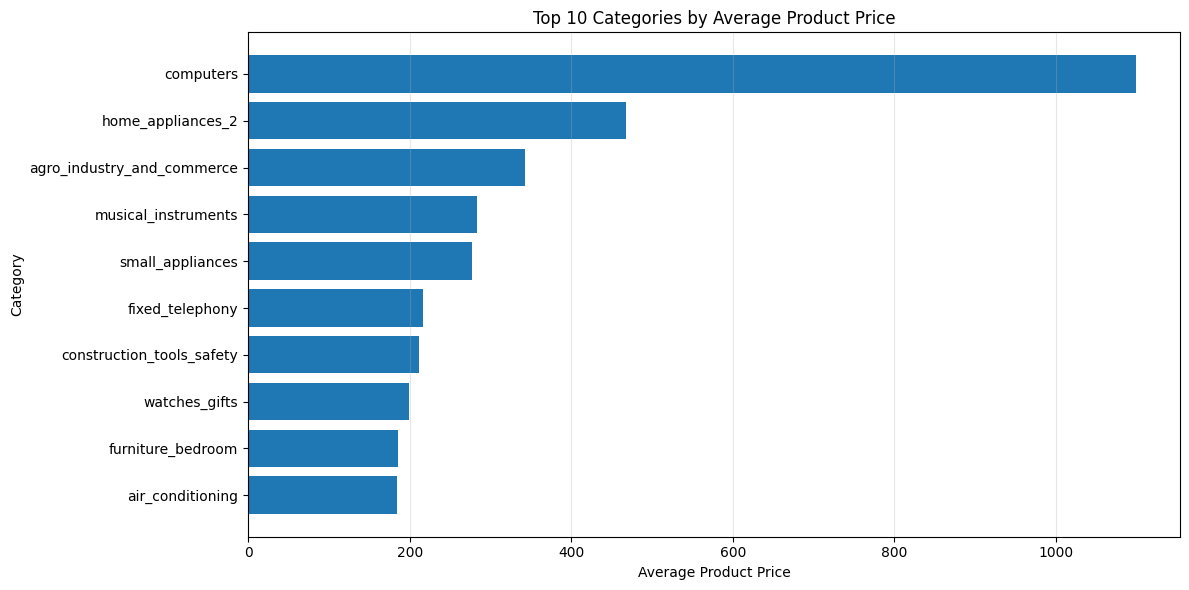

In [6]:
plt.figure(figsize=(12, 6))

plt.barh(categories_main["category"], categories_main["avg_product_price"])

plt.title("Top 10 Categories by Average Product Price")
plt.xlabel("Average Product Price")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:** Computers category clearly stands out as a premium segment. The average product price is approximately 1100, more than twice as high as the second-ranked category Home Appliances 2.

High-price categories are mainly concentrated in electronics, home appliances, industrial equipment, and musical instruments, indicating that these product groups contribute significantly to revenue per sale.

The difference between the most expensive category and the other categories is substantial, indicating an extremely diverse price structure within the product catalog.

**Recommendation:** Focus marketing efforts on premium categories, as each sale in these categories generates significantly higher revenue.

Consider featuring high-priced categories more prominently on website to increase their visibility.

Track premium categories closely, as changes in their sales can have a significant impact on overall revenue.

Continue to monitor both the average price and sales volume, as high-priced categories aren't always the most popular.

## Which product categories sell the most of units?

The analysis below uses data on the number of units sold in each category, calculated in the previous section

In [7]:
categories_most_unit = categories.sort_values('units_sold', ascending = False).head(10)
categories_most_unit

,category,units_sold,avg_product_price
14,bed_bath_table,10953,93.438762
0,health_beauty,9465,130.283330
2,sports_leisure,8431,113.254958
5,furniture_decor,8160,87.246040
12,computers_accessories,7644,116.264339
6,housewares,6795,90.600249
1,watches_gifts,5859,199.040276
15,telephony,4430,69.945876
8,garden_tools,4268,110.237882
7,auto,4140,139.847017


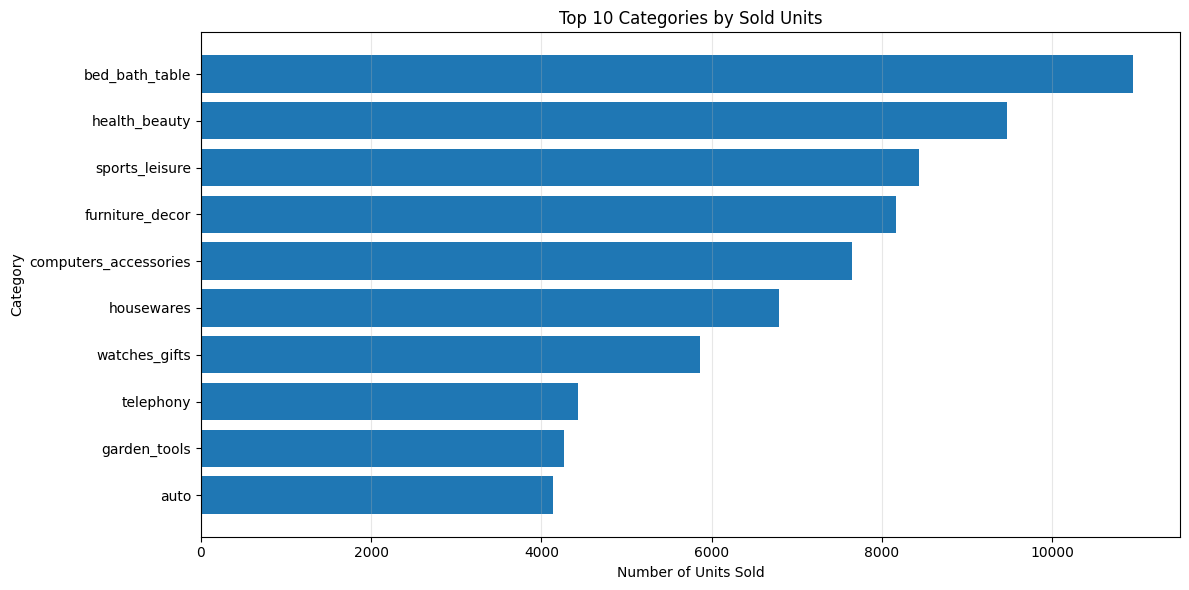

In [8]:
plt.figure(figsize=(12, 6))

plt.barh(categories_most_unit["category"], categories_most_unit["units_sold"])

plt.title("Top 10 Categories by Sold Units")
plt.xlabel("Number of Units Sold")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:** Bed, Bath and Table category is the largest in sales volume. More than 10000 items were sold in this category.

Health & Beauty and Sports & Leisure categories are also among the best-selling, indicating consistently high demand from customers.

The top sellers are primarily everyday items that customers purchase regularly, rather than expensive single-use products.

**Recommendation:** Maintain sufficient inventory levels for best-selling categories to reduce the risk of stockouts.

Prioritize these categories in marketing campaigns, as they are already demonstrating high demand from customers.

Consider using best-selling categories to promote related products through cross-selling recommendations.

## Which product categories receive the highest customer ratings?

**Note:** Customer reviews in the Olist dataset are submitted at the order level rather than for individual products. Therefore, if an order contains multiple product categories, the same review score is associated with each category represented in that order.

In [9]:
query = """
select pt.product_category_name_english as category, round(avg(r.review_score),2) as score, count(*) as review_count
from `Olist.olist_order_reviews_dataset` r
join `Olist.olist_orders_dataset` o
on r.order_id = o.order_id
join `Olist.olist_order_items_dataset` oi
on oi.order_id = r.order_id
join `Olist.olist_products_dataset` pr
on pr.product_id = oi.product_id
join `Olist.product_category_translation` pt
on pr.product_category_name = pt.product_category_name
where o.order_status = 'delivered'
group by category
"""

reviews = client.query(query).to_dataframe()
reviews

,category,score,review_count
0,health_beauty,4.19,9456
1,computers_accessories,3.98,7672
2,garden_tools,4.08,4254
3,auto,4.12,4117
4,toys,4.21,4007
...,...,...,...
68,flowers,4.42,31
69,arts_and_craftmanship,4.13,24
70,portable_kitchen_appliances,3.43,14
71,cds_dvds_musicals,4.64,14


In [10]:
reviews.sort_values('review_count').head(20)

,category,score,review_count
59,security_and_services,2.50,2
72,fashion_childrens_clothes,5.00,7
42,pc_gaming,3.63,8
40,la_cuisine,4.00,13
70,portable_kitchen_appliances,3.43,14
71,cds_dvds_musicals,4.64,14
69,arts_and_craftmanship,4.13,24
62,home_comfort_2,3.63,27
57,fashion_sport,4.37,30
68,flowers,4.42,31


**Notes:** To reduce the impact of very small sample sizes, categories with fewer than 100 customer reviews were excluded from the analysis.

In [11]:
reviews_main = reviews[reviews['review_count'] >= 100].sort_values('score', ascending = False).head(10)
reviews_main

,category,score,review_count
25,books_general_interest,4.51,533
60,books_technical,4.39,264
61,food_drink,4.37,271
41,luggage_accessories,4.35,1073
48,fashion_shoes,4.29,256
32,food,4.26,487
43,furniture_bedroom,4.25,103
26,stationery,4.24,2459
23,small_appliances,4.23,657
28,home_appliances,4.23,789


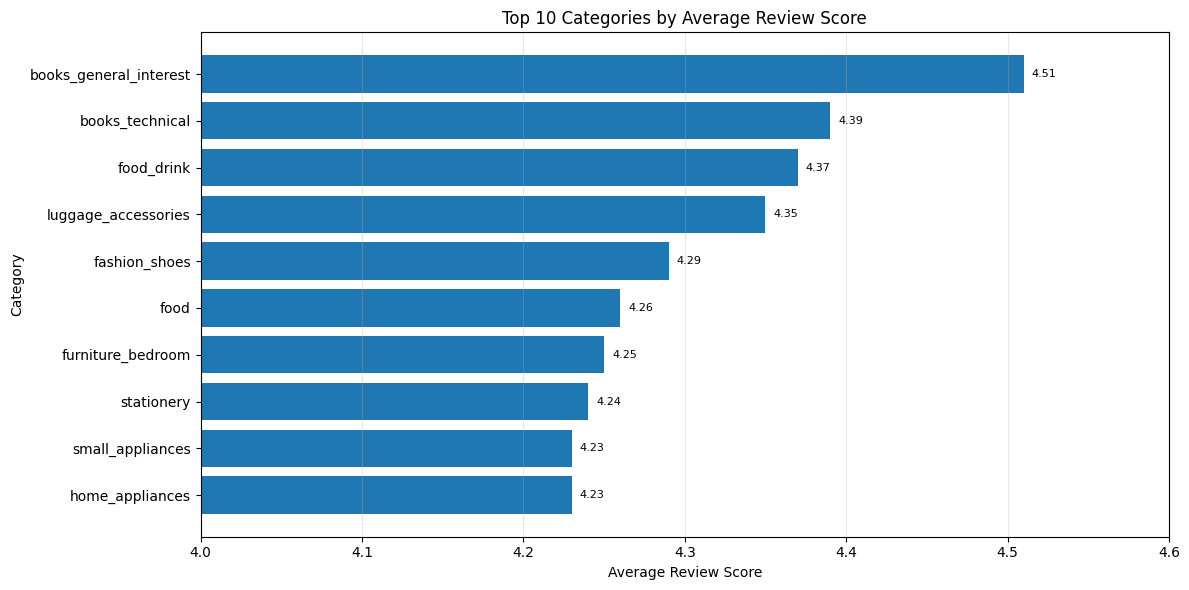

In [12]:
plt.figure(figsize=(12, 6))

plt.barh(reviews_main["category"], reviews_main["score"])

plt.title("Top 10 Categories by Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()

for i, value in enumerate(reviews_main['score']):
    plt.text(value + 0.005, i, f'{value:.2f}', va='center', fontsize=8)

plt.xlim(4.0, 4.6)

plt.tight_layout()
plt.show()

**Insight:** The product category with the highest rating is Books General Interest, with an average rating of 4.51.

All categories in the top 10 demonstrate a consistently high level of customer satisfaction: average ratings range from 4.23 to 4.51.

The difference between the categories with the highest and lowest ratings in the top 10 is relatively small (0.28 points), indicating a consistently high level of customer satisfaction across all top-performing categories.

Some of the categories with the highest ratings (Small Appliances and Furniture Bedroom) are also among the categories with higher prices, indicating that customers are willing to give excellent ratings even to relatively expensive products.

**Recommendation:** Display customer ratings prominently on product pages, especially in categories where reviews consistently receive high ratings.

Analyze what these top-rated categories have in common (product quality, packaging, delivery quality, or seller performance) and apply these approaches to categories with lower ratings.

## Which product categories experience the longest delivery delays?

In [13]:
query = """
select pt.product_category_name_english as category,
    round(avg(date_diff(o.order_delivered_customer_date, o.order_estimated_delivery_date, day)), 1) as avg_delay_days
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on o.order_id = oi.order_id
join `Olist.olist_products_dataset` p
on oi.product_id = p.product_id
join `Olist.product_category_translation` pt
on p.product_category_name = pt.product_category_name
where o.order_status = 'delivered' and o.order_delivered_customer_date > o.order_estimated_delivery_date
group by category
order by avg_delay_days desc
"""
delays = client.query(query).to_dataframe()
delays

,category,avg_delay_days
0,home_appliances_2,19.2
1,furniture_mattress_and_upholstery,15.2
2,air_conditioning,14.4
3,music,12.0
4,food_drink,11.9
...,...,...
63,art,2.5
64,cine_photo,2.4
65,arts_and_craftmanship,2.0
66,party_supplies,0.0


In [14]:
delays_top = delays.head(10)
delays_top

,category,avg_delay_days
0,home_appliances_2,19.2
1,furniture_mattress_and_upholstery,15.2
2,air_conditioning,14.4
3,music,12.0
4,food_drink,11.9
5,home_confort,11.8
6,home_comfort_2,11.6
7,drinks,11.3
8,signaling_and_security,10.7
9,office_furniture,10.4


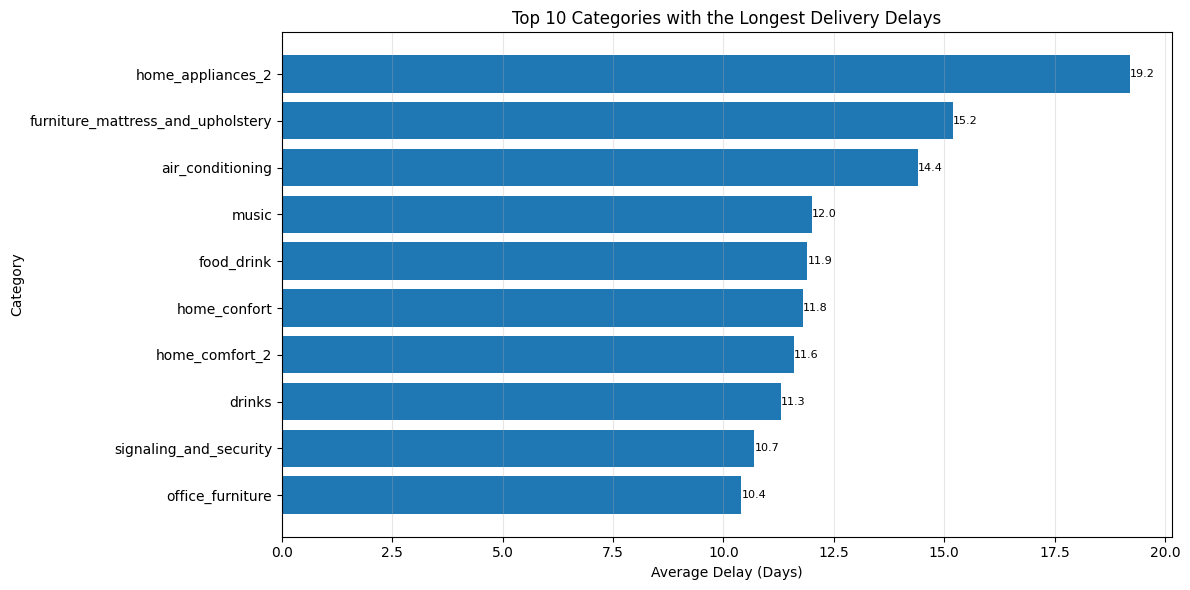

In [15]:
plt.figure(figsize=(12, 6))

plt.barh(delays_top["category"], delays_top["avg_delay_days"])

plt.title("Top 10 Categories with the Longest Delivery Delays")
plt.xlabel("Average Delay (Days)")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.3)
plt.gca().invert_yaxis()

for i, value in enumerate(delays_top['avg_delay_days']):
    plt.text(value + 0.005, i, f'{value}', va='center', fontsize=8)


plt.tight_layout()
plt.show()

**Insight:** Home Appliances-2 category has the longest average delivery delay (19.2 days), which significantly exceeds the figures for all other categories.

In the top 10 categories with the longest delays, the average delay is 10–19 days past the promised delivery date, which likely has a noticeable impact on future shopping choices for similar purchases.

**Recommendation:** Analyze the order fulfillment process for categories with the longest delivery delays and identify the root causes (supplier lead times, warehouse operations or delivery partners).

Consider extending estimated delivery times for categories where delays occur consistently to better align with actual performance.

Prioritize optimizing operational processes in categories with the longest delays before increasing sales volume as delivery reliability is a critical component of the customer experience.

## Is higher product price associated with better ratings?

In [16]:
query = """
select oi.product_id as product, count(*) as units_sold, avg(oi.price) as product_price,
    avg(r.review_score) as avg_review_score,count(r.review_id) as review_count
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on o.order_id = oi.order_id
join `Olist.olist_order_reviews_dataset` r
on o.order_id = r.order_id
where o.order_status = 'delivered'
group by product_id
having count(review_id) >= 3
"""
price_rate = client.query(query).to_dataframe()
price_rate

,product,units_sold,product_price,avg_review_score,review_count
0,473795a355d29305c3ea6b156833adf5,83,55.466265,4.349398,83
1,eba7488e1c67729f045ab43fac426f2e,25,217.996000,4.640000,25
2,5b8423dc7f23089c9c59c5d140eb5a1c,22,130.880909,4.636364,22
3,027cdd14a677a5834bc67a9789db5021,39,87.379487,3.743590,39
4,9fe172fa8e662ca8572cf12abf8bce23,29,49.900000,4.034483,29
...,...,...,...,...,...
8844,c1617123e66d2491ca93ceadfd36203e,21,52.847143,4.714286,21
8845,d48bacc1dcd9c86bf1ed4ed2a303336c,21,42.280476,4.571429,21
8846,d99526b1e4fa5f57b8bde34a7337b5ee,21,58.522857,4.571429,21
8847,09b0d15a8cc9a84e7af7e0225f67dc45,21,67.000000,4.095238,21


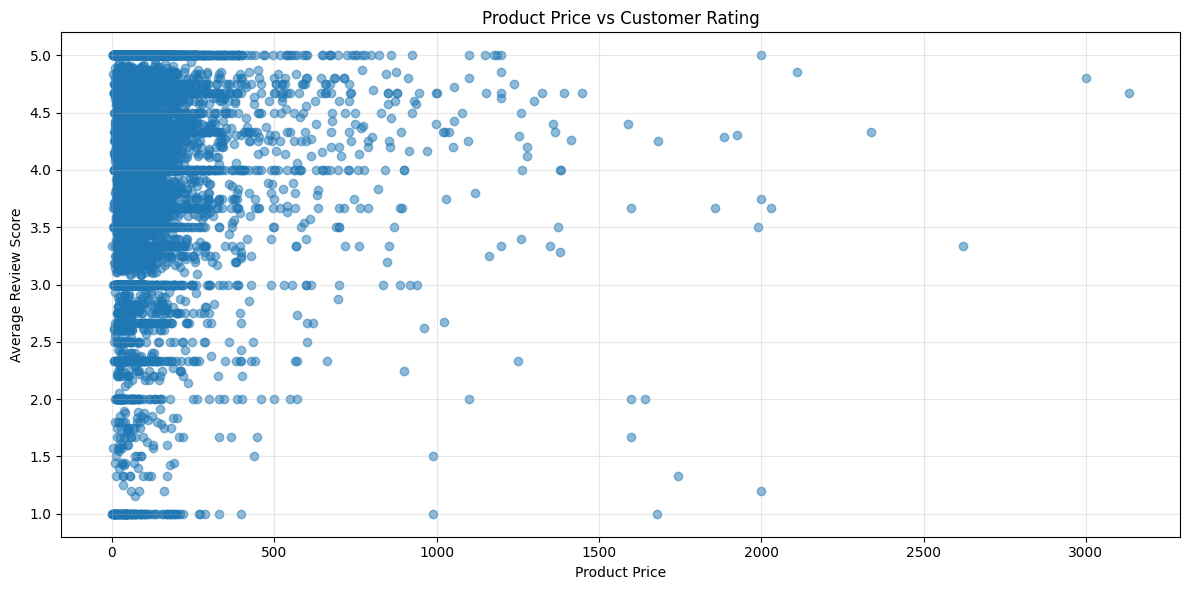

In [17]:
plt.figure(figsize=(12, 6))

plt.scatter(price_rate['product_price'], price_rate['avg_review_score'],alpha=0.5)

plt.title('Product Price vs Customer Rating')
plt.xlabel('Product Price')
plt.ylabel('Average Review Score')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
correlation = price_rate['product_price'].corr(price_rate['avg_review_score'])

print(f'Correlation coefficient: {correlation:.3f}')

Correlation coefficient: -0.002


**Insight:** The correlation coefficient between a product's price and its average review rating is -0.002, indicating complete lack of correlation.

Products with both low and high prices receive a wide range of ratings from customers.

Higher-priced products do not always receive more positive customer reviews.

**Recommendation:** Customer ratings should not be used as a basis for raising prices, as no significant correlation between price and ratings was found.

Improving product quality and service is likely to have a greater impact on customer satisfaction than price changes.

## Is higher sales volume associated with higher revenue?

In [19]:
query = """
select
    oi.product_id as product,
    count(*) as units_sold,
    sum(oi.price) as revenue
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on o.order_id = oi.order_id
where o.order_status = 'delivered'
group by product
"""
sales_revenue = client.query(query).to_dataframe()
sales_revenue

,product,units_sold,revenue
0,473795a355d29305c3ea6b156833adf5,83,4603.70
1,7cd29da0653abeb444703cc5a957f479,17,650.30
2,eba7488e1c67729f045ab43fac426f2e,25,5449.90
3,cf1d8e226162a1d0ad61f29b7ed72d82,13,396.00
4,e9b3cf27d68caa64832c4a7c460abcb9,12,1920.90
...,...,...,...
32211,952e73f7e8bee61569a32b35c19bc981,11,595.00
32212,4f18ca9862f511ecba98258b2194d061,11,1000.00
32213,b05ec8d9cabec69e637318ebba813a09,11,1385.89
32214,90aaf7f993470e411207adabf5b998b6,11,2119.00


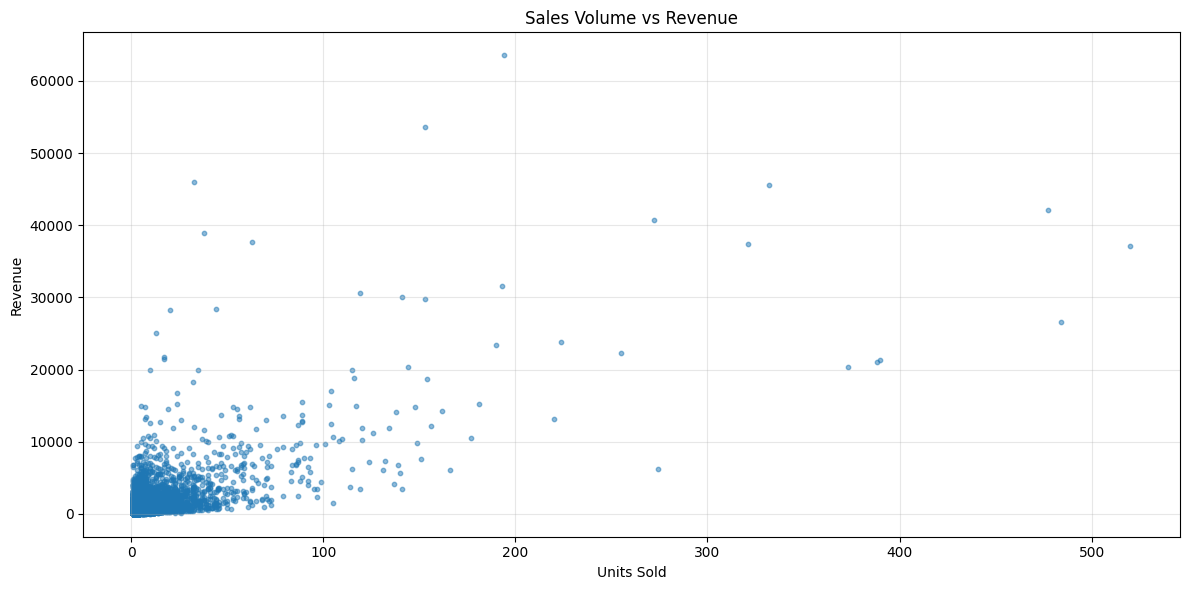

In [20]:
plt.figure(figsize=(12, 6))

plt.scatter(sales_revenue['units_sold'], sales_revenue['revenue'],alpha=0.5, s=10)

plt.title('Sales Volume vs Revenue')
plt.xlabel('Units Sold')
plt.ylabel('Revenue')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
corr = sales_revenue['units_sold'].corr(sales_revenue['revenue'])

print(f'Сorrelation coefficient: {corr:.3f}')

Сorrelation coefficient: 0.705


**Insight:** The correlation coefficient between sales volume and revenue is 0.705 indicating a moderate positive relationship.

Products with higher sales volume generally generate higher revenue.

However, products with the same revenue may have very different sales volumes, indicating that product price also plays an important role in determining total revenue.

**Recommendation:** Continue promoting high-volume products, as they are the main source of sales revenue.

Track high-priced products with lower sales volumes, as an increase in demand for them can significantly boost revenue.

## ABC

In [22]:
query = """
select c.product_category_name_english as category, round(sum(oi.price),2) as revenue
from `Olist.olist_orders_dataset` o
join `Olist.olist_order_items_dataset` oi
on  o.order_id = oi.order_id
join `Olist.olist_products_dataset` p
on oi.product_id = p.product_id
join `Olist.product_category_translation` c
on p.product_category_name = c.product_category_name
where o.order_status = 'delivered'
group by category
order by revenue desc
"""
df_revenue_cat = client.query(query).to_dataframe()
df_revenue_cat.head()

,category,revenue
0,health_beauty,1233131.72
1,watches_gifts,1166176.98
2,bed_bath_table,1023434.76
3,sports_leisure,954852.55
4,computers_accessories,888724.61


In [23]:
abc_table = df_revenue_cat.copy()
abc_table["category"] = abc_table["category"].str.replace("_", " ").str.title()
abc_table["share"] = (abc_table["revenue"] / abc_table["revenue"].sum() * 100).round(2)
abc_table["cumulative_share"] = abc_table["share"].cumsum()
def abc_category(cumulative_share):
    if cumulative_share <= 80:
        return "A"
    elif cumulative_share <= 95:
        return "B"
    else:
        return "C"
abc_table["ABC"] = abc_table["cumulative_share"].apply(abc_category)
abc_table

,category,revenue,share,cumulative_share,ABC
0,Health Beauty,1233131.72,9.45,9.45,A
1,Watches Gifts,1166176.98,8.94,18.39,A
2,Bed Bath Table,1023434.76,7.84,26.23,A
3,Sports Leisure,954852.55,7.32,33.55,A
4,Computers Accessories,888724.61,6.81,40.36,A
...,...,...,...,...,...
68,Flowers,1110.04,0.01,99.97,C
69,Home Comfort 2,760.27,0.01,99.98,C
70,Cds Dvds Musicals,730.00,0.01,99.99,C
71,Fashion Childrens Clothes,519.95,0.00,99.99,C


In [24]:
print("Category A products:\n")

for category in abc_table.loc[abc_table["ABC"] == "A", "category"]:
    print(f"- {category}")

print(f"\nCategory A contains {len(abc_table[abc_table['ABC']=='A'])} product categories.")
print(f"Category A generates approximately {abc_table.loc[abc_table['ABC']=='A','share'].sum():.1f}% of total revenue.")


Category A products:

- Health Beauty
- Watches Gifts
- Bed Bath Table
- Sports Leisure
- Computers Accessories
- Furniture Decor
- Housewares
- Cool Stuff
- Auto
- Toys
- Garden Tools
- Baby
- Perfumery
- Telephony
- Office Furniture
- Stationery

Category A contains 16 product categories.
Category A generates approximately 79.1% of total revenue.


In [25]:
print("Category B products:\n")

for category in abc_table.loc[abc_table["ABC"] == "B", "category"]:
    print(f"- {category}")

print(f"\nCategory B contains {len(abc_table[abc_table['ABC']=='B'])} product categories.")
print(f"Category B generates approximately {abc_table.loc[abc_table['ABC']=='B','share'].sum():.1f}% of total revenue.")

Category B products:

- Computers
- Pet Shop
- Musical Instruments
- Small Appliances
- Electronics
- Fashion Bags Accessories
- Consoles Games
- Construction Tools Construction
- Luggage Accessories
- Home Appliances 2
- Home Construction
- Home Appliances
- Agro Industry And Commerce
- Furniture Living Room
- Home Confort
- Fixed Telephony

Category B contains 16 product categories.
Category B generates approximately 15.7% of total revenue.


In [26]:
print("Category C products:\n")

for category in abc_table.loc[abc_table["ABC"] == "C", "category"]:
    print(f"- {category}")

print(f"\nCategory C contains {len(abc_table[abc_table['ABC']=='C'])} product categories.")
print(f"Category C generates approximately {abc_table.loc[abc_table['ABC']=='C','share'].sum():.1f}% of total revenue.")

Category C products:

- Air Conditioning
- Audio
- Small Appliances Home Oven And Coffee
- Kitchen Dining Laundry Garden Furniture
- Books General Interest
- Construction Tools Lights
- Construction Tools Safety
- Industry Commerce And Business
- Food
- Market Place
- Costruction Tools Garden
- Art
- Fashion Shoes
- Drinks
- Signaling And Security
- Furniture Bedroom
- Books Technical
- Costruction Tools Tools
- Food Drink
- Fashion Male Clothing
- Fashion Underwear Beach
- Christmas Supplies
- Tablets Printing Image
- Cine Photo
- Music
- Dvds Blu Ray
- Party Supplies
- Books Imported
- Furniture Mattress And Upholstery
- Portable Kitchen Appliances
- Fashio Female Clothing
- Fashion Sport
- La Cuisine
- Arts And Craftmanship
- Diapers And Hygiene
- Pc Gaming
- Flowers
- Home Comfort 2
- Cds Dvds Musicals
- Fashion Childrens Clothes
- Security And Services

Category C contains 41 product categories.
Category C generates approximately 5.2% of total revenue.


**Insight:** An ABC analysis shows that only 16 product categories fall into Category A, yet they account for 79.1% of total revenue.

**Recommendation:** Prioritize inventory management, pricing, and marketing investments for Category A products, as they generate the majority of the company's revenue. At the same time, periodically evaluate Category B products for growth opportunities and analyze Category C products to determine whether they should be optimized, repositioned, or discontinued.